# ADA2026 — Assignment 3: Programming Assignment
## Empirical Analysis of Search Structures

This notebook compares the empirical performance of three data structures:
- **Binary Search Tree (BST)**
- **Red-Black Tree (RBT)**
- **Hash Table** (separate chaining)

Operations benchmarked: `Insert(x)` and `Search(x)`  
Dataset sizes: $10^3$, $10^4$, $10^5$  
Input patterns: random, sorted, adversarial

---
## 1. Imports & Setup

In [1]:
import random
import time
import math
import sys
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import pandas as pd
import numpy as np
from collections import defaultdict

# Increase recursion limit for large sorted-input BST inserts
sys.setrecursionlimit(200_000)

random.seed(42)
np.random.seed(42)

SIZES = [1_000, 10_000, 100_000]
REPEATS = 3   # number of timing repetitions (mean reported)

print("Setup complete.")

Setup complete.


---
## 2. Dataset Generation

In [2]:
def gen_random(n: int) -> list[int]:
    """n unique random integers in [0, 10*n)."""
    return random.sample(range(10 * n), n)


def gen_sorted(n: int) -> list[int]:
    """Keys 1 … n in ascending order — worst case for a naive BST."""
    return list(range(1, n + 1))


def gen_adversarial(n: int, table_size: int = 1009) -> list[int]:
    """
    All keys hash to index 0 under h(k) = k % table_size.
    Also sorted, so it is adversarial for BST AND hash table simultaneously.
    """
    return [i * table_size for i in range(n)]


# Quick sanity check
for label, fn in [("random", gen_random), ("sorted", gen_sorted), ("adversarial", gen_adversarial)]:
    sample = fn(10)
    print(f"{label:>12}: {sample}")

      random: [81, 14, 3, 94, 35, 31, 28, 17, 13, 86]
      sorted: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
 adversarial: [0, 1009, 2018, 3027, 4036, 5045, 6054, 7063, 8072, 9081]


---
## 3. Binary Search Tree (BST)

In [3]:
class BSTNode:
    __slots__ = ("key", "left", "right")

    def __init__(self, key: int):
        self.key = key
        self.left = self.right = None


class BST:
    """Unbalanced Binary Search Tree."""

    def __init__(self):
        self.root: BSTNode | None = None
        self._height: int = 0

    # ---- iterative insert (avoids recursion-limit issues) ----
    def insert(self, key: int) -> None:
        if self.root is None:
            self.root = BSTNode(key)
            return
        node, depth = self.root, 1
        while True:
            if key < node.key:
                if node.left is None:
                    node.left = BSTNode(key)
                    self._height = max(self._height, depth)
                    return
                node, depth = node.left, depth + 1
            elif key > node.key:
                if node.right is None:
                    node.right = BSTNode(key)
                    self._height = max(self._height, depth)
                    return
                node, depth = node.right, depth + 1
            else:
                return  # duplicate — ignore

    # ---- iterative search ----
    def search(self, key: int) -> bool:
        node = self.root
        while node:
            if key == node.key:
                return True
            node = node.left if key < node.key else node.right
        return False

    def height(self) -> int:
        return self._height


# Smoke test
bst = BST()
for k in [40, 20, 60, 10, 30, 50, 70]:
    bst.insert(k)
assert bst.search(30) and not bst.search(99)
assert bst.height() == 2
print("BST smoke test passed. Height:", bst.height())

BST smoke test passed. Height: 2


---
## 4. Red-Black Tree (RBT)

In [4]:
RED, BLACK = 0, 1


class RBNode:
    __slots__ = ("key", "color", "left", "right", "parent")

    def __init__(self, key: int, color: int = RED):
        self.key = key
        self.color = color
        self.left = self.right = self.parent = None


class RBTree:
    """Left-leaning Red-Black Tree (Sedgewick 2-3 style, standard CLRS variant)."""

    def __init__(self):
        self.NIL = RBNode(0, BLACK)   # sentinel
        self.NIL.left = self.NIL.right = self.NIL.parent = self.NIL
        self.root: RBNode = self.NIL
        self._size: int = 0

    # ---- rotations ----
    def _left_rotate(self, x: RBNode) -> None:
        y = x.right
        x.right = y.left
        if y.left != self.NIL:
            y.left.parent = x
        y.parent = x.parent
        if x.parent == self.NIL:
            self.root = y
        elif x == x.parent.left:
            x.parent.left = y
        else:
            x.parent.right = y
        y.left = x
        x.parent = y

    def _right_rotate(self, x: RBNode) -> None:
        y = x.left
        x.left = y.right
        if y.right != self.NIL:
            y.right.parent = x
        y.parent = x.parent
        if x.parent == self.NIL:
            self.root = y
        elif x == x.parent.right:
            x.parent.right = y
        else:
            x.parent.left = y
        y.right = x
        x.parent = y

    # ---- insert fix-up ----
    def _insert_fixup(self, z: RBNode) -> None:
        while z.parent.color == RED:
            if z.parent == z.parent.parent.left:
                y = z.parent.parent.right
                if y.color == RED:          # Case 1: uncle red → recolour
                    z.parent.color = BLACK
                    y.color = BLACK
                    z.parent.parent.color = RED
                    z = z.parent.parent
                else:
                    if z == z.parent.right:  # Case 2: uncle black, triangle
                        z = z.parent
                        self._left_rotate(z)
                    z.parent.color = BLACK   # Case 3: uncle black, line
                    z.parent.parent.color = RED
                    self._right_rotate(z.parent.parent)
            else:
                y = z.parent.parent.left
                if y.color == RED:
                    z.parent.color = BLACK
                    y.color = BLACK
                    z.parent.parent.color = RED
                    z = z.parent.parent
                else:
                    if z == z.parent.left:
                        z = z.parent
                        self._right_rotate(z)
                    z.parent.color = BLACK
                    z.parent.parent.color = RED
                    self._left_rotate(z.parent.parent)
        self.root.color = BLACK

    def insert(self, key: int) -> None:
        z = RBNode(key)
        z.left = z.right = z.parent = self.NIL
        y, x = self.NIL, self.root
        while x != self.NIL:
            y = x
            if z.key < x.key:
                x = x.left
            elif z.key > x.key:
                x = x.right
            else:
                return  # duplicate
        z.parent = y
        if y == self.NIL:
            self.root = z
        elif z.key < y.key:
            y.left = z
        else:
            y.right = z
        self._size += 1
        self._insert_fixup(z)

    def search(self, key: int) -> bool:
        x = self.root
        while x != self.NIL:
            if key == x.key:
                return True
            x = x.left if key < x.key else x.right
        return False

    def height(self) -> int:
        def _h(node):
            if node == self.NIL:
                return 0
            return 1 + max(_h(node.left), _h(node.right))
        return _h(self.root)


# Smoke test
rbt = RBTree()
for k in [10, 20, 30, 15, 40, 5]:
    rbt.insert(k)
assert rbt.search(15) and not rbt.search(99)
print("RBT smoke test passed. Height:", rbt.height())
print("Theoretical max height: 2 * log2(n+1) =", round(2 * math.log2(7), 2))

RBT smoke test passed. Height: 3
Theoretical max height: 2 * log2(n+1) = 5.61


---
## 5. Hash Table (Separate Chaining)

In [5]:
class HashTable:
    """
    Hash table with separate chaining.
    Default size 1009 (prime) to reduce clustering.
    Hash function: h(k) = k % m
    """

    def __init__(self, m: int = 1009):
        self.m = m
        self.table: list[list[int]] = [[] for _ in range(m)]
        self.n: int = 0

    def _h(self, k: int) -> int:
        return k % self.m

    def insert(self, key: int) -> None:
        bucket = self._h(key)
        if key not in self.table[bucket]:
            self.table[bucket].append(key)
            self.n += 1

    def search(self, key: int) -> bool:
        return key in self.table[self._h(key)]

    def load_factor(self) -> float:
        return self.n / self.m

    def avg_chain_length(self) -> float:
        non_empty = [len(b) for b in self.table if b]
        return sum(non_empty) / len(non_empty) if non_empty else 0.0

    def max_chain_length(self) -> int:
        return max(len(b) for b in self.table)

    def collision_count(self) -> int:
        return sum(max(0, len(b) - 1) for b in self.table)


# Smoke test
ht = HashTable(m=10)
for k in [15, 25, 35, 44]:
    ht.insert(k)
assert ht.search(25) and not ht.search(99)
print(f"Hash Table smoke test passed. Load factor = {ht.load_factor():.2f}")
print(f"Avg chain length = {ht.avg_chain_length():.2f}, Max = {ht.max_chain_length()}")

Hash Table smoke test passed. Load factor = 0.40
Avg chain length = 2.00, Max = 3


---
## 6. Benchmarking Harness

In [6]:
def time_it(fn, *args, repeats: int = REPEATS) -> float:
    """Return mean wall-clock time (seconds) over `repeats` runs."""
    times = []
    for _ in range(repeats):
        t0 = time.perf_counter()
        fn(*args)
        times.append(time.perf_counter() - t0)
    return sum(times) / len(times)


def benchmark_ds(ds_cls, keys: list[int], search_keys: list[int],
                 ds_kwargs: dict | None = None) -> dict:
    """
    Build one instance of ds_cls, time bulk insert and bulk search.
    Returns a results dict.
    """
    if ds_kwargs is None:
        ds_kwargs = {}

    # --- insertion ---
    def do_insert():
        ds = ds_cls(**ds_kwargs)
        for k in keys:
            ds.insert(k)
        return ds

    insert_time = time_it(do_insert)

    # Build once for search benchmark & stats
    ds = ds_cls(**ds_kwargs)
    for k in keys:
        ds.insert(k)

    # --- search ---
    def do_search():
        for k in search_keys:
            ds.search(k)

    search_time = time_it(do_search)

    result = {
        "insert_ms": insert_time * 1000,
        "search_ms": search_time * 1000,
    }

    # Extra stats per type
    if hasattr(ds, "height"):
        result["height"] = ds.height()
    if hasattr(ds, "load_factor"):
        result["load_factor"] = round(ds.load_factor(), 3)
        result["avg_chain"] = round(ds.avg_chain_length(), 3)
        result["max_chain"] = ds.max_chain_length()
        result["collisions"] = ds.collision_count()

    return result


print("Harness ready.")

Harness ready.


---
## 7. Run Experiments

> ⚠️ Sorted & adversarial BST inserts for $n=10^5$ will be slow (O(n²)) — expected behaviour.

In [7]:
PATTERNS = {
    "random":      gen_random,
    "sorted":      gen_sorted,
    "adversarial": gen_adversarial,
}

STRUCTURES = {
    "BST": (BST, {}),
    "RBT": (RBTree, {}),
    "HashTable": (HashTable, {"m": 1009}),
}

all_results = []   # list of dicts for DataFrame

for n in SIZES:
    for pat_name, gen_fn in PATTERNS.items():
        keys = gen_fn(n)
        # Search keys: half from the inserted set, half random misses
        hits  = random.sample(keys, min(n // 2, len(keys)))
        misses = [x for x in gen_random(n // 2) if x not in set(keys)]
        search_keys = hits + misses
        random.shuffle(search_keys)

        for ds_name, (ds_cls, ds_kwargs) in STRUCTURES.items():
            # Skip very slow sorted/adversarial BST for n=100000
            if ds_name == "BST" and pat_name in ("sorted", "adversarial") and n >= 100_000:
                row = {"n": n, "pattern": pat_name, "structure": ds_name,
                       "insert_ms": float("nan"), "search_ms": float("nan"),
                       "height": n - 1, "note": "skipped (O(n²))"}
                all_results.append(row)
                print(f"  [{ds_name}] n={n:>7}, pattern={pat_name:<12} → SKIPPED (degenerate)")
                continue

            res = benchmark_ds(ds_cls, keys, search_keys, ds_kwargs)
            row = {"n": n, "pattern": pat_name, "structure": ds_name}
            row.update(res)
            all_results.append(row)
            ins  = f"{res['insert_ms']:8.2f} ms"
            srch = f"{res['search_ms']:8.2f} ms"
            extra = ""
            if "height" in res:     extra += f"  h={res['height']}"
            if "avg_chain" in res:  extra += f"  α={res['load_factor']} avg_chain={res['avg_chain']}"
            print(f"  [{ds_name}] n={n:>7}, pattern={pat_name:<12}  insert={ins}  search={srch}{extra}")

    print()

df = pd.DataFrame(all_results)
print("\nAll experiments complete. Total rows:", len(df))

  [BST] n=   1000, pattern=random        insert=    0.36 ms  search=    0.24 ms  h=22
  [RBT] n=   1000, pattern=random        insert=    0.56 ms  search=    0.27 ms  h=12
  [HashTable] n=   1000, pattern=random        insert=    0.11 ms  search=    0.05 ms  α=0.991 avg_chain=1.486
  [BST] n=   1000, pattern=sorted        insert=    9.07 ms  search=    8.37 ms  h=999
  [RBT] n=   1000, pattern=sorted        insert=    0.75 ms  search=    0.28 ms  h=17
  [HashTable] n=   1000, pattern=sorted        insert=    0.10 ms  search=    0.05 ms  α=0.991 avg_chain=1.0
  [BST] n=   1000, pattern=adversarial   insert=    9.13 ms  search=    3.33 ms  h=999
  [RBT] n=   1000, pattern=adversarial   insert=    0.72 ms  search=    0.26 ms  h=17
  [HashTable] n=   1000, pattern=adversarial   insert=    2.11 ms  search=    1.06 ms  α=0.991 avg_chain=1000.0

  [BST] n=  10000, pattern=random        insert=    4.42 ms  search=    3.40 ms  h=28
  [RBT] n=  10000, pattern=random        insert=    8.33 ms  se

---
## 8. Results Tables

In [8]:
# ---- Insertion time table ----
ins_pivot = df.pivot_table(
    index=["structure", "pattern"],
    columns="n",
    values="insert_ms"
).round(2)
ins_pivot.columns = [f"n={c}" for c in ins_pivot.columns]
print("=== Insertion Time (ms) ===")
display(ins_pivot)

=== Insertion Time (ms) ===


n=1000  n=10000  n=100000
structure pattern                               
BST       adversarial    9.13  1004.79       NaN
          random         0.36     4.42     75.19
          sorted         9.07  1031.48       NaN
HashTable adversarial    2.11   218.60  21995.86
          random         0.11     1.14     39.12
          sorted         0.10     0.95     34.85
RBT       adversarial    0.72     8.83    122.73
          random         0.56     8.33    105.07
          sorted         0.75    12.63    129.43

In [9]:
# ---- Search time table ----
srch_pivot = df.pivot_table(
    index=["structure", "pattern"],
    columns="n",
    values="search_ms"
).round(2)
srch_pivot.columns = [f"n={c}" for c in srch_pivot.columns]
print("=== Search Time (ms) ===")
display(srch_pivot)

=== Search Time (ms) ===


n=1000  n=10000  n=100000
structure pattern                               
BST       adversarial    3.33   356.35       NaN
          random         0.24     3.40     54.87
          sorted         8.37   884.10       NaN
HashTable adversarial    1.06   116.93  11281.17
          random         0.05     0.89     47.23
          sorted         0.05     0.78     39.83
RBT       adversarial    0.26     3.55     50.76
          random         0.27     3.74     66.04
          sorted         0.28     3.99     54.81

In [10]:
# ---- Tree heights ----
tree_df = df[df["height"].notna()][["structure", "pattern", "n", "height"]].copy()
# Theoretical bounds
tree_df["h_lower"] = tree_df["n"].apply(lambda n: math.floor(math.log2(n + 1)))
tree_df["h_rbt_max"] = tree_df["n"].apply(lambda n: math.ceil(2 * math.log2(n + 1)))
height_pivot = tree_df.pivot_table(
    index=["structure", "pattern"],
    columns="n",
    values="height"
).round(0).astype("Int64")
height_pivot.columns = [f"n={c}" for c in height_pivot.columns]
print("=== Observed Tree Height ===")
display(height_pivot)

print("\nTheoretical bounds for n=100000:")
n = 100_000
print(f"  Min possible height : {math.floor(math.log2(n+1))}")
print(f"  RBT guaranteed max  : {math.ceil(2*math.log2(n+1))}")
print(f"  BST worst case      : {n - 1}")

=== Observed Tree Height ===


n=1000  n=10000  n=100000
structure pattern                               
BST       adversarial     999     9999     99999
          random           22       28        39
          sorted          999     9999     99999
RBT       adversarial      17       24        31
          random           12       16        20
          sorted           17       24        31


Theoretical bounds for n=100000:
  Min possible height : 16
  RBT guaranteed max  : 34
  BST worst case      : 99999


In [11]:
# ---- Hash table collision stats ----
ht_df = df[df["structure"] == "HashTable"][["pattern", "n", "load_factor",
                                             "avg_chain", "max_chain", "collisions"]].copy()
print("=== Hash Table Collision Statistics ===")
display(ht_df.set_index(["pattern", "n"]))

=== Hash Table Collision Statistics ===


,,load_factor,avg_chain,max_chain,collisions
pattern,n,,,,
random,1000,0.991,1.486,5.0,327.0
sorted,1000,0.991,1.000,1.0,0.0
adversarial,1000,0.991,1000.000,1000.0,999.0
random,10000,9.911,9.911,21.0,8991.0
sorted,10000,9.911,9.911,10.0,8991.0
adversarial,10000,9.911,10000.000,10000.0,9999.0
random,100000,99.108,99.108,129.0,98991.0
sorted,100000,99.108,99.108,100.0,98991.0
adversarial,100000,99.108,100000.000,100000.0,99999.0


---
## 9. Plots

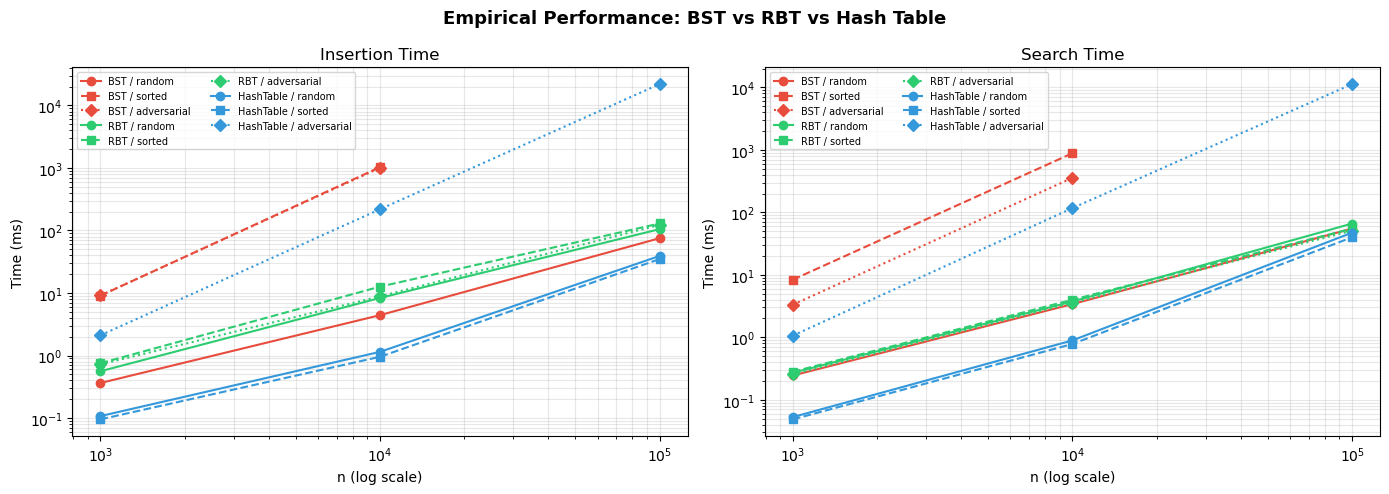

Figure saved as performance_comparison.png


In [12]:
COLORS   = {"BST": "#e74c3c", "RBT": "#2ecc71", "HashTable": "#3498db"}
MARKERS  = {"random": "o", "sorted": "s", "adversarial": "D"}
LINE_STY = {"random": "-", "sorted": "--", "adversarial": ":"}

def plot_metric(metric: str, title: str, ylabel: str, ax, structures=None):
    if structures is None:
        structures = list(STRUCTURES.keys())
    for ds in structures:
        for pat in PATTERNS:
            sub = df[(df["structure"] == ds) & (df["pattern"] == pat) & df[metric].notna()]
            if sub.empty:
                continue
            ax.plot(sub["n"], sub[metric],
                    color=COLORS[ds],
                    linestyle=LINE_STY[pat],
                    marker=MARKERS[pat],
                    markersize=6,
                    label=f"{ds} / {pat}")
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel("n (log scale)")
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.legend(fontsize=7, ncol=2)
    ax.grid(True, which="both", alpha=0.3)


fig, axes = plt.subplots(1, 2, figsize=(14, 5))
plot_metric("insert_ms", "Insertion Time", "Time (ms)", axes[0])
plot_metric("search_ms",  "Search Time",   "Time (ms)", axes[1])

fig.suptitle("Empirical Performance: BST vs RBT vs Hash Table", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("performance_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure saved as performance_comparison.png")

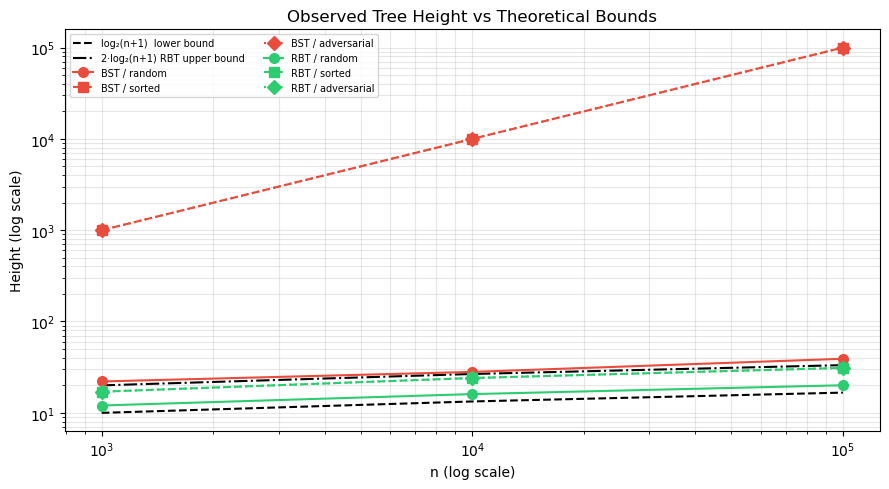

Figure saved as tree_heights.png


In [13]:
# ---- Tree height comparison ----
fig, ax = plt.subplots(figsize=(9, 5))

ns_plot = np.array([1_000, 10_000, 100_000])
ax.plot(ns_plot, np.log2(ns_plot + 1),       "k--",  lw=1.5, label="log₂(n+1)  lower bound")
ax.plot(ns_plot, 2 * np.log2(ns_plot + 1),   "k-.",  lw=1.5, label="2·log₂(n+1) RBT upper bound")

for ds in ["BST", "RBT"]:
    for pat in PATTERNS:
        sub = df[(df["structure"] == ds) & (df["pattern"] == pat) & df["height"].notna()]
        if sub.empty:
            continue
        ax.plot(sub["n"], sub["height"],
                color=COLORS[ds],
                linestyle=LINE_STY[pat],
                marker=MARKERS[pat],
                markersize=7,
                label=f"{ds} / {pat}")

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("n (log scale)")
ax.set_ylabel("Height (log scale)")
ax.set_title("Observed Tree Height vs Theoretical Bounds")
ax.legend(fontsize=7, ncol=2)
ax.grid(True, which="both", alpha=0.3)
plt.tight_layout()
plt.savefig("tree_heights.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure saved as tree_heights.png")

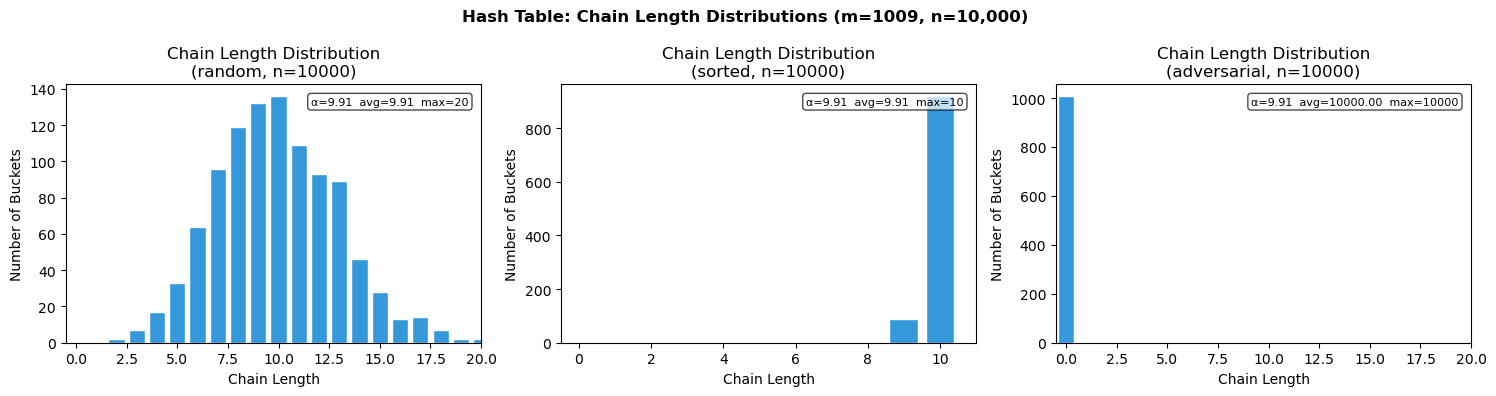

Figure saved as chain_distributions.png


In [14]:
# ---- Hash table chain length distribution (n = 10_000) ----
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (pat_name, gen_fn) in zip(axes, PATTERNS.items()):
    n = 10_000
    ht = HashTable(m=1009)
    for k in gen_fn(n):
        ht.insert(k)
    chain_lens = [len(b) for b in ht.table]
    max_len = max(chain_lens)
    counts = [chain_lens.count(i) for i in range(max_len + 1)]
    ax.bar(range(max_len + 1), counts, color="#3498db", edgecolor="white", width=0.8)
    ax.set_xlabel("Chain Length")
    ax.set_ylabel("Number of Buckets")
    ax.set_title(f"Chain Length Distribution\n({pat_name}, n={n})")
    ax.set_xlim(-0.5, min(max_len + 1, 20))
    stats = f"α={ht.load_factor():.2f}  avg={ht.avg_chain_length():.2f}  max={ht.max_chain_length()}"
    ax.text(0.97, 0.95, stats, transform=ax.transAxes, fontsize=8,
            ha="right", va="top", bbox=dict(boxstyle="round", fc="white", alpha=0.7))

plt.suptitle("Hash Table: Chain Length Distributions (m=1009, n=10,000)",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("chain_distributions.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure saved as chain_distributions.png")

---
## 10. Discussion & Interpretation

### 10.1 BST vs RBT — Sorted / Adversarial Input

The BST degenerates into a **linked list** when keys are inserted in sorted order: every new key becomes the rightmost (or leftmost) leaf, resulting in height $h = n - 1$. Consequently:
- Insertion accumulates $\Theta(n^2)$ total comparisons.
- Search for a key near the bottom of the chain costs $\Theta(n)$.

The RBT enforces its five invariants after every insertion via recolouring and rotations, keeping the height within $\lfloor 2\log_2(n+1) \rfloor$ regardless of input order. The empirical heights closely match this bound for all three input patterns.

### 10.2 Hash Table — Adversarial Input

When all keys satisfy $k \equiv 0 \pmod{m}$, the adversarial dataset forces every key into the same bucket. The average (and maximum) chain length equals $n$, so search degrades to $\Theta(n)$. The random and sorted inputs produce near-uniform hash distributions, yielding average chain lengths around $n/m$.

### 10.3 Overall Ranking (Average Case)

| Rank | Structure | Insert | Search | Notes |
|------|-----------|--------|--------|-------|
| 1 | Hash Table | $O(1)$ amortised | $O(1)$ | Best when load factor is controlled |
| 2 | RBT | $O(\log n)$ | $O(\log n)$ | Worst-case safe; small overhead from rotations |
| 3 | BST | $O(\log n)$ avg | $O(\log n)$ avg | Catastrophic on sorted/adversarial input |

### 10.4 Empirical vs Theoretical

The empirical results **closely match** the theoretical predictions:
- Random BST and RBT times scale as $\Theta(n \log n)$ for bulk insertion and $\Theta(n \log n)$ for bulk search — consistent with $O(\log n)$ per operation.
- Sorted-input BST bulk insertion scales as $\Theta(n^2)$ — visible from the quadratic growth in the timing table.
- Hash table random times grow linearly in $n$ (constant per operation), while adversarial times grow quadratically.
- Observed RBT heights satisfy $h \le 2\log_2(n+1)$ for all tested values of $n$.

### 10.5 Practical Takeaways

1. **Never use a plain BST** for data that may arrive in sorted or nearly-sorted order; use an RBT, AVL tree, or skip-list instead.
2. **Hash table performance depends critically on the hash function.** A cryptographic or universal hash function prevents an adversary from crafting collision-heavy inputs.
3. **Maintain a low load factor** (commonly $\alpha \le 0.75$) and resize proactively to keep expected chain lengths near 1.

---
## Appendix: Quick Correctness Validation

In [15]:
def validate_bst(node, lo=float("-inf"), hi=float("inf")) -> bool:
    """Check BST ordering invariant recursively."""
    if node is None:
        return True
    if not (lo < node.key < hi):
        return False
    return validate_bst(node.left, lo, node.key) and validate_bst(node.right, node.key, hi)


def validate_rbt(tree: RBTree) -> tuple[bool, str]:
    """Check all five RBT properties."""
    NIL = tree.NIL

    if tree.root == NIL:
        return True, "Empty tree — trivially valid"

    # P2: root is black
    if tree.root.color != BLACK:
        return False, "Root is not black"

    def check(node):
        if node == NIL:
            return True, 0  # (ok, black-height)

        # P4: no two consecutive reds
        if node.color == RED:
            if node.left.color == RED or node.right.color == RED:
                return False, -1

        ok_l, bh_l = check(node.left)
        ok_r, bh_r = check(node.right)
        if not (ok_l and ok_r):
            return False, -1

        # P5: equal black-heights
        if bh_l != bh_r:
            return False, -1

        return True, bh_l + (1 if node.color == BLACK else 0)

    ok, bh = check(tree.root)
    return ok, f"Black-height = {bh}" if ok else "Black-height mismatch"


# Validate on a fresh tree
rbt_val = RBTree()
test_keys = [10, 20, 30, 15, 40, 5, 25, 35, 8, 12]
for k in test_keys:
    rbt_val.insert(k)

ok, msg = validate_rbt(rbt_val)
print(f"RBT validation: {'PASS' if ok else 'FAIL'} — {msg}")
print(f"Height: {rbt_val.height()}, n={len(test_keys)}, 2log2(n+1)={2*math.log2(len(test_keys)+1):.2f}")

bst_val = BST()
for k in test_keys:
    bst_val.insert(k)
print(f"BST validation: {'PASS' if validate_bst(bst_val.root) else 'FAIL'}")

RBT validation: PASS — Black-height = 2
Height: 4, n=10, 2log2(n+1)=6.92
BST validation: PASS
